# Mansueto imputation investigation (DLSD routes 146 / 147)

Side notebook: understand how Mansueto `bus_stop_time` is built, quality-check DLSD segment durations, and recommend filters for [`dlsd_travel_time_146_147.ipynb`](dlsd_travel_time_146_147.ipynb).

**Data:** cached last-30-day Mansueto parquets under `data/mansueto/` (see `scripts/cache_dlsd_parquets.py`). Run that script first if the cache is missing.

**Code:** shared logic in [`dlsd_run_quality.py`](dlsd_run_quality.py); ETL reference in [`../cta-stop-watch/cta-stop-watch/report_automation/interpolation.py`](../cta-stop-watch/cta-stop-watch/report_automation/interpolation.py).

In [1]:
%matplotlib inline

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOKS = Path.cwd() if (Path.cwd() / "dlsd_run_quality.py").is_file() else Path.cwd() / "notebooks"
REPO_ROOT = NOTEBOOKS.parent if NOTEBOOKS.name == "notebooks" else NOTEBOOKS
sys.path.insert(0, str(NOTEBOOKS))

from dlsd_run_quality import (
    PARQUET_COLS,
    add_quality_flags,
    build_dlsd_runs,
    load_dlsd_boundaries,
    local_parquet_path,
)

_style = REPO_ROOT / "notebooks" / "cta_analysis.mplstyle"
if _style.is_file():
    plt.style.use(_style)

ROUTE_COLORS = {"146": "#9D8AB8", "147": "#4E79A7"}

dlsd_boundaries = load_dlsd_boundaries()
print(f"{len(dlsd_boundaries)} DLSD PIDs in snapshot")

18 LSD PIDs in snapshot


## 1. How Mansueto imputes `bus_stop_time`

Mansueto converts ~5-minute **GPS vehicle pings** into **stop arrival times** by:

1. Ordering pattern stops and bus locations along the route (`seg_combined`).
2. For each interval between consecutive pings with a timestamp (`typ=="B"`), computing `ping_dist` and `ping_time_diff`.
3. Assigning each stop (`typ=="S"`) a time linear in distance within that interval:

   `bus_stop_time = ping_time + ping_time_diff * (accumulated_distance / ping_dist)`

4. Stops before the first / after the last ping are extrapolated using implied speed.

**Raw pings:** CTA `getvehicles` `tmstmp` is `YYYYMMdd HH:MM` (minute resolution). Ghost Bus scrapes about every 5 minutes, not aligned to clock :00/:05.

**Published `speed_mph`:** speed of the **ping interval** (not stop-to-stop), clamped to **[1, 115] mph**, then forward/back-filled. Our DLSD metric **`implied_dlsd_mph`** = hop miles / `dlsd_minutes` is a different quantity.

Published parquets only include `typ=="S"` rows (no raw pings).

## 2. Full-trip stop sequences (sample)

Load a full cached PID and inspect consecutive stop times, focusing on the DLSD entry/exit hop.

<Axes: >

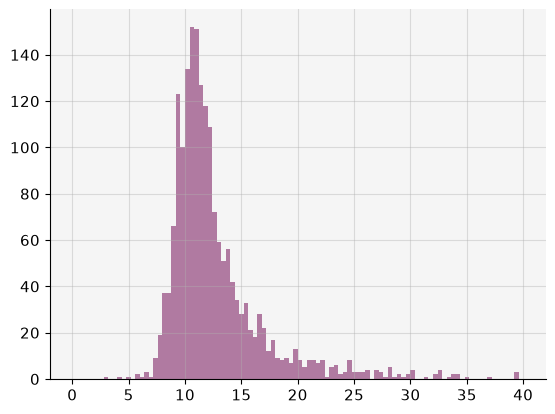

In [11]:
runs_probe["bracket_minutes"].hist(bins=np.linspace(0, 40, 101))

In [2]:
SAMPLE_PID = "7451"  # dominant 146 SB in snapshot
info = dlsd_boundaries[SAMPLE_PID]
entry_stpid = str(info["entry_stpid"])
exit_stpid = str(info["exit_stpid"])

df = pd.read_parquet(local_parquet_path(SAMPLE_PID), columns=PARQUET_COLS)
df = df.sort_values(["unique_trip_vehicle_day", "stop_sequence"])

# trip with median DLSD duration among runs that have both stops
runs_probe = build_dlsd_runs({SAMPLE_PID: info}, prefer_local=True)
med = runs_probe["dlsd_minutes"].median()
trip_id = runs_probe.loc[
    (runs_probe["dlsd_minutes"] - med).abs().idxmin(), "unique_trip_vehicle_day"
]

trip = df[df["unique_trip_vehicle_day"] == trip_id].copy()
trip["gap_min"] = trip["bus_stop_time"].diff().dt.total_seconds() / 60
trip["dlsd_hop"] = trip["stpid"].isin({entry_stpid, exit_stpid})

display(trip[["stop_sequence", "stpid", "bus_stop_time", "gap_min", "speed_mph", "seg_combined", "dlsd_hop"]])

hop = trip.loc[trip["stpid"].isin({entry_stpid, exit_stpid}), "gap_min"].sum()
print(f"Trip {trip_id}: sum of gaps at entry+exit rows (not DLSD span alone): see entry/exit times above")
ent = trip.loc[trip["stpid"] == entry_stpid, "bus_stop_time"].iloc[0]
ex = trip.loc[trip["stpid"] == exit_stpid, "bus_stop_time"].iloc[0]
print(f"DLSD span (exit - entry): {(ex - ent).total_seconds() / 60:.2f} min")

,stop_sequence,stpid,bus_stop_time,gap_min,speed_mph,seg_combined,lsd_hop
63478,1,14668,2026-07-13 10:05:01.530199478,NaN,6.086459,0.0,False
41916,2,14669,2026-07-13 10:21:39.158708487,16.627142,6.086459,3.0,False
17394,3,1041,2026-07-13 10:22:30.673181335,0.858575,6.086459,7.0,False
57775,4,4845,2026-07-13 10:23:59.999999999,1.488780,6.086459,11.0,False
33331,5,4846,2026-07-13 10:24:43.878677408,0.731311,9.426209,13.0,False
10344,6,4851,2026-07-13 10:25:32.084972700,0.803438,9.426209,17.0,False
46143,7,4852,2026-07-13 10:26:10.297733037,0.636879,9.426209,20.0,False
8690,8,4853,2026-07-13 10:26:36.702467378,0.440079,9.426209,23.0,False
33332,9,4854,2026-07-13 10:27:02.205012905,0.425042,9.426209,26.0,False
70890,10,4855,2026-07-13 10:27:43.780804252,0.692930,9.426209,29.0,False


Trip 1467451.0176443942026-07-13: sum of gaps at entry+exit rows (not LSD span alone): see entry/exit times above
LSD span (exit - entry): 9.11 min


## 3. Ping-bracket analysis and 5-minute bins

- **`dlsd_minutes`**: imputed exit − entry at DLSD boundary stops.
- **`bracket_minutes`**: time from stop *before* entry to stop *after* exit (wider, often spans more ping intervals).
- **`same_ping_interval_proxy`**: entry and exit share the same Mansueto `speed_mph` (heuristic for same ping interval).
- **`dlsd_minutes_bin`**: floor to 5-minute buckets (honest resolution given ~5 min pings).

In [3]:
dlsd_runs = build_dlsd_runs(dlsd_boundaries, prefer_local=True)
print(f"Runs (last-30d cache): {len(dlsd_runs):,}")
print(f"Date range: {dlsd_runs['entry_time'].min()} -> {dlsd_runs['entry_time'].max()}")

display(
    dlsd_runs.groupby("same_ping_interval_proxy", as_index=False)
    .agg(runs=("dlsd_minutes", "count"), median_dlsd=("dlsd_minutes", "median"))
)

display(
    dlsd_runs[["dlsd_minutes", "bracket_minutes", "dlsd_minutes_bin"]]
    .describe(percentiles=[0.5, 0.95])
)

Runs (last-30d cache): 10,952
Date range: 2026-06-27 09:33:11.153005721 -> 2026-07-28 00:28:39.585857208


,same_ping_interval_proxy,runs,median_lsd
0,False,10052,10.330758
1,True,900,12.545538


,lsd_minutes,bracket_minutes,lsd_minutes_bin
count,10952.000000,10949.000000,10952.000000
mean,12.081067,15.522937,9.474069
std,10.566627,14.544010,10.695479
min,0.323740,1.564558,0.000000
50%,10.355426,12.600587,10.000000
95%,20.475094,28.943058,20.000000
max,354.187883,363.792385,350.000000


## 4. Structural validity flags

| Flag | Rule |
|------|------|
| `ok_consecutive` | `exit_sequence == entry_sequence + 1` |
| `ok_time_order` | `exit_time > entry_time` |
| `ok_times_present` | both times non-null |
| `analysis_ok` | all of the above |

Compare to legacy `[1, 120]` minute filter (full-history notebook used ~2k drops).

In [4]:
flag_cols = ["ok_times_present", "ok_time_order", "ok_consecutive", "analysis_ok", "legacy_drop"]
summary = {c: (~dlsd_runs[c] if c != "analysis_ok" else ~dlsd_runs[c]).sum() if c.startswith("ok") or c in ("analysis_ok", "legacy_drop") else 0 for c in flag_cols}
# fix counts for True=pass
for c in flag_cols:
    if c == "legacy_drop":
        summary[c] = int(dlsd_runs[c].sum())
    else:
        summary[c] = int((~dlsd_runs[c]).sum())

print("Failures (count of runs that fail each check):")
for c in flag_cols:
    print(f"  {c}: {summary[c]:,}")

print(f"\nLegacy would drop: {summary['legacy_drop']:,}")
print(f"Structural analysis_ok keeps: {dlsd_runs['analysis_ok'].sum():,} / {len(dlsd_runs):,}")

display(
    dlsd_runs.groupby(["route", "rtdir"], as_index=False)
    .agg(
        runs=("dlsd_minutes", "count"),
        analysis_ok=("analysis_ok", "sum"),
        median_all=("dlsd_minutes", "median"),
        median_ok=("dlsd_minutes", lambda s: s[dlsd_runs.loc[s.index, "analysis_ok"]].median()),
    )
)

Failures (count of runs that fail each check):
  ok_times_present: 0
  ok_time_order: 0
  ok_consecutive: 0
  analysis_ok: 0
  legacy_drop: 51

Legacy would drop: 51
Structural analysis_ok keeps: 10,952 / 10,952


,route,rtdir,runs,analysis_ok,median_all,median_ok
0,146,Northbound,2959,2959,8.435938,8.435938
1,146,Southbound,2748,2748,9.064408,9.064408
2,147,Northbound,2626,2626,12.136575,12.136575
3,147,Southbound,2619,2619,12.321122,12.321122


## 5. Diagnostics

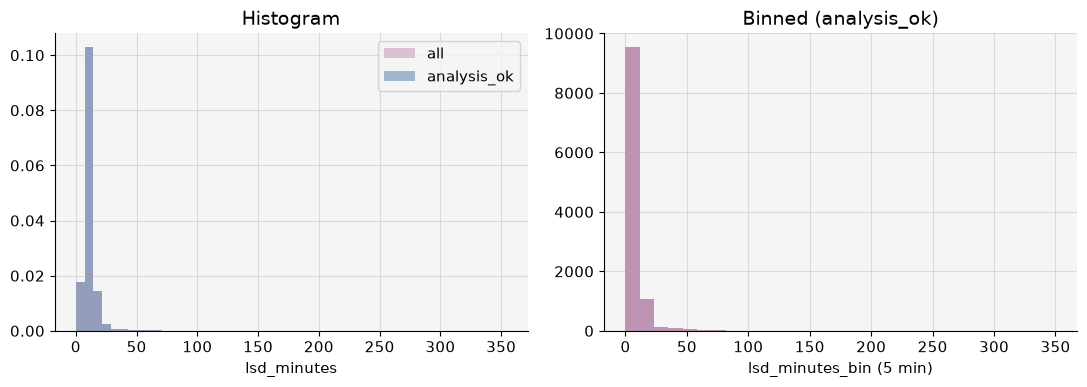

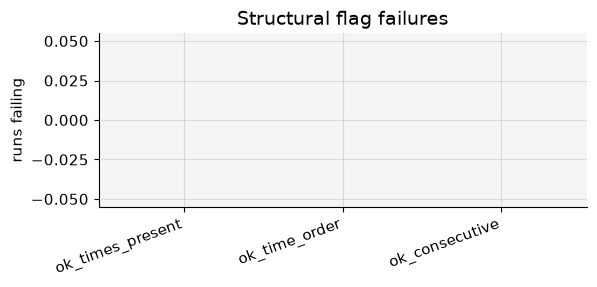

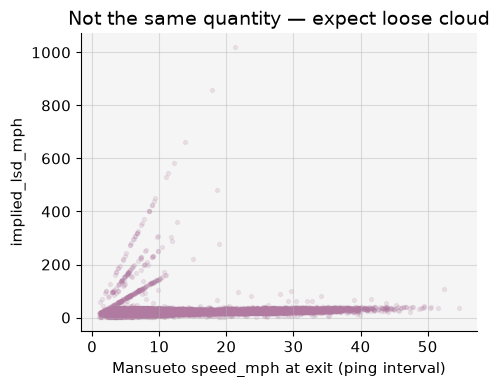

,unique_trip_vehicle_day,pid,route,lsd_minutes,bracket_minutes,entry_sequence,exit_sequence
9235,1474524.0106391141062026-07-06,4524,147,354.187883,363.792385,15,16
10024,1474524.031143662026-06-28,4524,147,278.468157,292.454186,15,16
9481,1474524.0106393643512026-07-27,4524,147,215.074845,222.316063,15,16
9539,1474524.0106394343972026-07-22,4524,147,201.766341,209.589016,15,16
9633,1474524.0106395243552026-07-22,4524,147,194.558442,200.342673,15,16
8722,1474524.01000418640172026-07-22,4524,147,192.431935,196.733371,15,16
4133,1467451.0269443342026-07-25,7451,146,182.243127,201.995418,30,31
5103,1466399.0217243982026-07-24,6399,146,168.289787,184.421253,10,11
9615,1474524.0106395141682026-06-30,4524,147,147.468505,152.268773,15,16
9477,1474524.0106393641662026-07-08,4524,147,144.342856,151.470684,15,16


In [5]:
ok = dlsd_runs[dlsd_runs["analysis_ok"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, sub, ax in [
    ("all", dlsd_runs["dlsd_minutes"], axes[0]),
    ("analysis_ok", ok["dlsd_minutes"], axes[0]),
]:
    pass
axes[0].hist(dlsd_runs["dlsd_minutes"], bins=50, alpha=0.4, density=True, label="all")
axes[0].hist(ok["dlsd_minutes"], bins=50, alpha=0.5, density=True, label="analysis_ok")
axes[0].set_xlabel("dlsd_minutes")
axes[0].legend()
axes[0].set_title("Histogram")

axes[1].hist(ok["dlsd_minutes_bin"], bins=30, color=ROUTE_COLORS.get("146", "C0"), alpha=0.8)
axes[1].set_xlabel("dlsd_minutes_bin (5 min)")
axes[1].set_title("Binned (analysis_ok)")
plt.tight_layout()
plt.show()

fail_counts = {
    "ok_times_present": (~dlsd_runs["ok_times_present"]).sum(),
    "ok_time_order": (~dlsd_runs["ok_time_order"]).sum(),
    "ok_consecutive": (~dlsd_runs["ok_consecutive"]).sum(),
}
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(list(fail_counts.keys()), list(fail_counts.values()), color="#9D8AB8")
ax.set_ylabel("runs failing")
ax.set_title("Structural flag failures")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(ok["exit_speed_mph"], ok["implied_dlsd_mph"], alpha=0.15, s=8)
ax.set_xlabel("Mansueto speed_mph at exit (ping interval)")
ax.set_ylabel("implied_dlsd_mph")
ax.set_title("Not the same quantity — expect loose cloud")
plt.tight_layout()
plt.show()

# Tail inspection
tail = ok.nlargest(10, "dlsd_minutes")[
    ["unique_trip_vehicle_day", "pid", "route", "dlsd_minutes", "bracket_minutes", "entry_sequence", "exit_sequence"]
]
display(tail)

## 6. Recommendations (for main DLSD notebook)

1. **Filter:** use `analysis_ok` (consecutive DLSD stops + ordered times), not `[1, 120]` minutes or posted speed limits.
2. **Reporting:** note ~5-minute input resolution; show **`dlsd_minutes_bin`** or medians by hour for robust summaries.
3. **Speed plots:** use **`implied_dlsd_mph`**; do not compare to Mansueto column `speed_mph` or a 45 mph cap line.
4. **Data scope:** this notebook uses **last-30-day cache** for speed; full-history analysis in the main notebook should call `build_dlsd_runs(..., prefer_local=False)`.

See knowledge-vault note `2026-09-23-mansueto-imputed-stop-times.md`.